Loading data...
2026-04-09 16:17:17 - src.utils.file_handler - INFO - Loading CSV from: c:\Users\M.SAMLY\Desktop\student performance prediction\data\processed\merged_raw_data.csv
2026-04-09 16:17:18 - src.utils.file_handler - INFO - Successfully loaded 32593 rows and 28 columns
Shape: (32593, 28)
Missing Values Analysis:
                        Missing Count  Percentage
date_unregistration             22521       69.10
avg_score                        6773       20.78
std_score                        6773       20.78
min_score                        6773       20.78
max_score                        6773       20.78
num_assessments                  6773       20.78
avg_submission_date              6773       20.78
num_banked                       6773       20.78
total_clicks                     3365       10.32
avg_clicks_per_session           3365       10.32
total_sessions                   3365       10.32
first_activity_date              3365       10.32
last_activity_date         

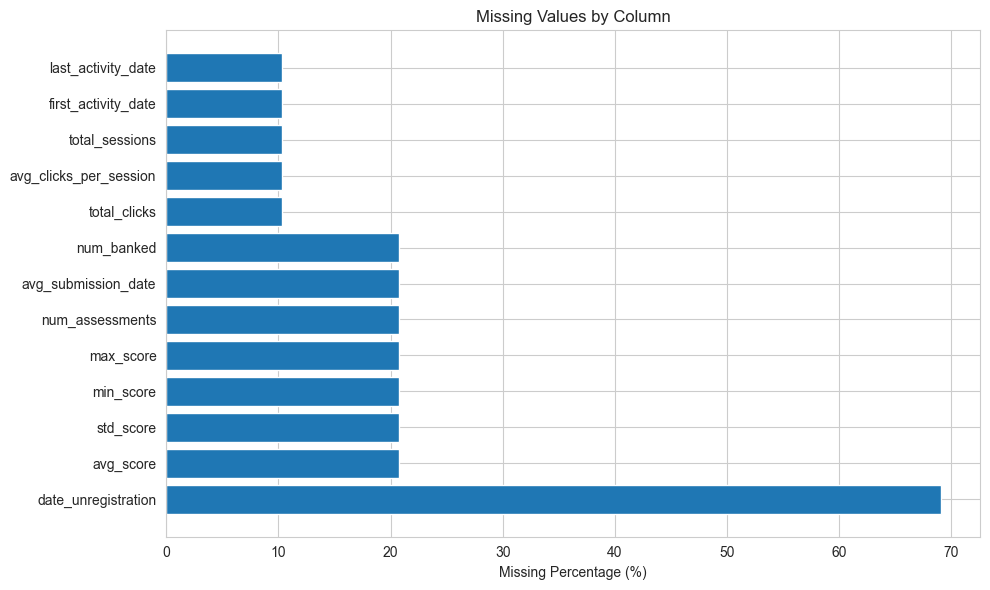

Data Types:
code_module                    object
code_presentation              object
id_student                      int64
gender                         object
region                         object
highest_education              object
imd_band                       object
age_band                       object
num_of_prev_attempts            int64
studied_credits                 int64
disability                     object
final_result                   object
module_presentation_length      int64
date_registration              object
date_unregistration           float64
is_unregistered                 int64
total_clicks                  float64
avg_clicks_per_session        float64
total_sessions                float64
first_activity_date           float64
last_activity_date            float64
avg_score                     float64
std_score                     float64
min_score                     float64
max_score                     float64
num_assessments               float64


: 

In [ ]:
### notebooks/02_data_preprocessing.ipynb

# Cell 1: Setup
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import PROCESSED_DATA_DIR
from src.utils.file_handler import load_csv

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Cell 2: Load Data
print("Loading data...")
df = load_csv(PROCESSED_DATA_DIR / "merged_raw_data.csv")
print(f"Shape: {df.shape}")
df.head()

# Cell 3: Check Missing Values
print("Missing Values Analysis:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Percentage', ascending=False)

print(missing_df)

# Plot missing values
if len(missing_df) > 0:
    plt.figure(figsize=(10, 6))
    plt.barh(missing_df.index, missing_df['Percentage'])
    plt.xlabel('Missing Percentage (%)')
    plt.title('Missing Values by Column')
    plt.tight_layout()
    plt.show()

# Cell 4: Data Types
print("Data Types:")
print(df.dtypes)

print("\nNumeric Columns:")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(numeric_cols)

print("\nCategorical Columns:")
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(cat_cols)

# Cell 5: Duplicate Check
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

if duplicates > 0:
    print("\nDuplicate rows:")
    print(df[df.duplicated(keep=False)])

# Cell 6: Statistical Summary
print("Statistical Summary of Numeric Columns:")
df[numeric_cols].describe().T

# Cell 7: Value Distributions
print("Value Counts for Categorical Columns:")
for col in cat_cols[:5]:  # First 5 categorical columns
    print(f"\n{col}:")
    print(df[col].value_counts())

# Cell 8: Outlier Detection
print("Outlier Detection (IQR Method):")

outlier_summary = []
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    
    outlier_summary.append({
        'Column': col,
        'Outlier Count': len(outliers),
        'Percentage': (len(outliers) / len(df) * 100)
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df[outlier_df['Outlier Count'] > 0])

# Cell 9: Load Cleaned Data
print("Loading cleaned data after preprocessing...")
cleaned_df = load_csv(PROCESSED_DATA_DIR / "cleaned_data.csv")
print(f"\nCleaned data shape: {cleaned_df.shape}")
print(f"Original data shape: {df.shape}")

# Cell 10: Compare Before/After
print("Comparison Before and After Cleaning:")
print(f"Rows removed: {len(df) - len(cleaned_df)}")
print(f"Missing values before: {df.isnull().sum().sum()}")
print(f"Missing values after: {cleaned_df.isnull().sum().sum()}")

# Cell 11: Load Featured Data
featured_df = load_csv(PROCESSED_DATA_DIR / "featured_data.csv")
print(f"\nFeatured data shape: {featured_df.shape}")

new_features = set(featured_df.columns) - set(df.columns)
print(f"\nNew features created: {len(new_features)}")
print("New feature names:")
for feat in sorted(new_features):
    print(f"  - {feat}")

# Cell 12: Summary
print("="*60)
print("PREPROCESSING SUMMARY")
print("="*60)
print(f"Original rows: {len(df)}")
print(f"Cleaned rows: {len(cleaned_df)}")
print(f"Final features: {featured_df.shape[1]}")
print(f"New features added: {len(new_features)}")
print("\nPreprocessing complete!")